#Leveraging Agglomerative Clustering for Premium Real Estate Targeting

## Import Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from matplotlib import pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

In [2]:
# load dataset and show the first five sample
url = "https://raw.githubusercontent.com/royhandaus/data_mining_royhan/refs/heads/main/Property%20Market%20Segmentation/Dataset/property_data_clustering_clean.csv"
df = pd.read_csv(url)
df.head()

,Area Category,Nama Daerah,Luas Tanah (m2),Luas Bangunan (m2),Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran (dari Owner),Terjual/Belum,Arah Hadap Rumah,Posisi Rumah,Lebar Jalan Depan Rumah (ROW)
0,Standard,Citraland,240,300,4,3,2,3500000000,Belum,Utara,Standard,1-2 Mobil
1,Below Standard,Setro Baru Utara,30,60,2,1,2,287799000,Belum,Utara,Standard,< 1 Mobil
2,Standard,Kenjeran,170,170,5,4,2,2699999999,Belum,Selatan,Cul De Sac/Ujung Gang Buntu,1-2 Mobil
3,Sangat Premium,Kenjeran,187,250,5,5,2,3100000000,Belum,Utara,Standard,1-2 Mobil
4,Premium,Kenjeran,350,600,5,5,2,5000000000,Belum,Barat,Standard,1-2 Mobil


In [3]:
# rename thecolumn
df = df.rename(columns={"Luas Tanah (m2)": "Luas Tanah", "Luas Bangunan (m2)": "Luas Bangunan","Harga Penawaran (dari Owner)" :"Harga Penawaran" , "Lebar Jalan Depan Rumah (ROW)" :"lebar Jalan Depan Rumah", "Tingkat/Lantai " : "Tingkat/Lantai"})
df.head()

,Area Category,Nama Daerah,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran,Terjual/Belum,Arah Hadap Rumah,Posisi Rumah,lebar Jalan Depan Rumah
0,Standard,Citraland,240,300,4,3,2,3500000000,Belum,Utara,Standard,1-2 Mobil
1,Below Standard,Setro Baru Utara,30,60,2,1,2,287799000,Belum,Utara,Standard,< 1 Mobil
2,Standard,Kenjeran,170,170,5,4,2,2699999999,Belum,Selatan,Cul De Sac/Ujung Gang Buntu,1-2 Mobil
3,Sangat Premium,Kenjeran,187,250,5,5,2,3100000000,Belum,Utara,Standard,1-2 Mobil
4,Premium,Kenjeran,350,600,5,5,2,5000000000,Belum,Barat,Standard,1-2 Mobil


In [4]:
# describe data
df.describe()

,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran
count,308.000000,308.000000,308.000000,308.000000,308.000000,3.080000e+02
mean,226.951299,266.688312,4.275974,3.337662,1.840909,5.014301e+09
std,201.821447,213.161697,1.643804,1.627215,0.507932,8.311434e+09
min,14.000000,14.000000,1.000000,1.000000,1.000000,1.600000e+08
25%,96.000000,120.000000,3.000000,2.000000,2.000000,1.400000e+09
50%,162.500000,200.000000,4.000000,3.000000,2.000000,2.699500e+09
75%,283.000000,328.750000,5.000000,4.000000,2.000000,4.891667e+09
max,1561.000000,1200.000000,13.000000,13.000000,4.000000,9.900000e+10


In [5]:
# Check for info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Area Category            308 non-null    object
 1   Nama Daerah              308 non-null    object
 2   Luas Tanah               308 non-null    int64 
 3   Luas Bangunan            308 non-null    int64 
 4   Jumlah Kamar             308 non-null    int64 
 5   Jumlah Kamar Mandi       308 non-null    int64 
 6   Tingkat/Lantai           308 non-null    int64 
 7   Harga Penawaran          308 non-null    int64 
 8   Terjual/Belum            308 non-null    object
 9   Arah Hadap Rumah         308 non-null    object
 10  Posisi Rumah             308 non-null    object
 11  lebar Jalan Depan Rumah  308 non-null    object
dtypes: int64(6), object(6)
memory usage: 29.0+ KB


In [6]:
# Display unique values for each column
for column in df.columns:
    print(f"Unique values in column '{column}':")
    print(df[column].unique())
    print("-" * 30)

Unique values in column 'Area Category':
['Standard' 'Below Standard' 'Sangat Premium' 'Premium']
------------------------------
Unique values in column 'Nama Daerah':
['Citraland' 'Setro Baru Utara' 'Kenjeran' 'Gubeng' 'Sawahan' 'Mulyorejo'
 'Tegalsari' 'Tambaksari' 'Kalilom Lor Timur' 'Jelidro Manukan' 'Kalilom'
 'Bulak Cumpat barat' 'Tambak Wedi' 'Lebak Jaya'
 'Simo Gunung Kramat Timur' 'Medokan Ayu' 'Lebak Rejo' 'Medokan Sawah'
 'Klampis Ngasem' 'Medokan Sawah Timur' 'Citraland Golf Avenue'
 'Wisata Semanggi' 'Kedung Klinter' 'Gading Indah Regency'
 'Gunung Anyar Mas' 'Kutisari Utara' 'Mulyosari Tengah' 'Kapas Madya'
 'Bratang Gede' 'Citraland Utara' 'Lebak Jaya Utara' 'Mulyosari Timur'
 'Pakuwon City' 'Pakuwon city' 'Pakuwon City Florence' 'Pantai Mentari'
 'Royal Residence' 'Villa Kalijudan Indah' 'Sutorejo Timur'
 'Springville Residence' 'Sukomanunggal' 'Surabaya Pusat' 'Su' 'Mulyosari'
 'Krukah Selatan' 'Mulyosari Utara' 'Pondok Benowo Indah' 'Kenjeran Indah'
 'Tenggilis' 'Wism

In [7]:
# Drop the 'Nama Daerah' column
df = df.drop('Nama Daerah', axis=1)
df.head()

,Area Category,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran,Terjual/Belum,Arah Hadap Rumah,Posisi Rumah,lebar Jalan Depan Rumah
0,Standard,240,300,4,3,2,3500000000,Belum,Utara,Standard,1-2 Mobil
1,Below Standard,30,60,2,1,2,287799000,Belum,Utara,Standard,< 1 Mobil
2,Standard,170,170,5,4,2,2699999999,Belum,Selatan,Cul De Sac/Ujung Gang Buntu,1-2 Mobil
3,Sangat Premium,187,250,5,5,2,3100000000,Belum,Utara,Standard,1-2 Mobil
4,Premium,350,600,5,5,2,5000000000,Belum,Barat,Standard,1-2 Mobil


# EDA

/tmp/ipykernel_1719/3924143984.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Area Category', palette='viridis')


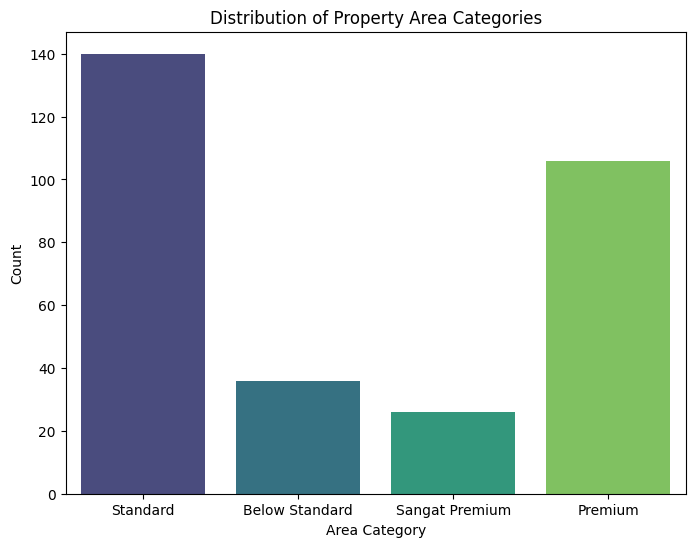

In [8]:
# Create a bar chart of 'Area Category'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Area Category', palette='viridis')
plt.title('Distribution of Property Area Categories')
plt.xlabel('Area Category')
plt.ylabel('Count')
plt.show()

Based on the bar chart above, we can observe the distribution of property area categories in the dataset. The chart shows the count of properties falling into each category: 'Standard', 'Below Standard', 'Sangat Premium', and 'Premium'. This gives us an idea of the prevalence of each property type in the dataset.

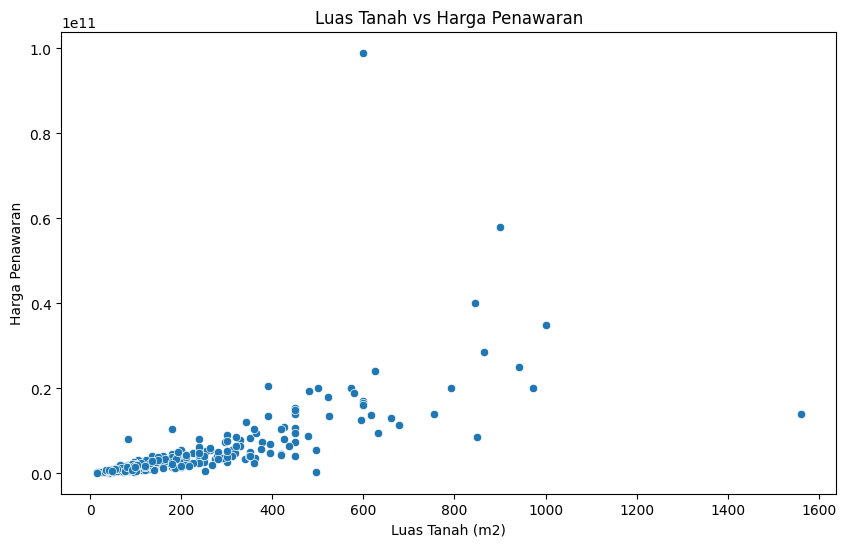

In [9]:
# Create a scatter plot of 'Luas Tanah' vs 'Harga Penawaran'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Luas Tanah', y='Harga Penawaran')
plt.title('Luas Tanah vs Harga Penawaran')
plt.xlabel('Luas Tanah (m2)')
plt.ylabel('Harga Penawaran')
plt.show()

The scatter plot above shows the relationship between 'Luas Tanah' (Land Area) and 'Harga Penawaran' (Offer Price). Each point represents a property in the dataset. We can observe how the offer price tends to increase as the land area increases, although there is a significant spread in prices for similar land areas, suggesting other factors influence the price.

## Data Transformation

In [10]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding to each categorical column
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Area Category,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran,Terjual/Belum,Arah Hadap Rumah,Posisi Rumah,lebar Jalan Depan Rumah
0,3,240,300,4,3,2,3500000000,0,3,2,0
1,0,30,60,2,1,2,287799000,0,3,2,1
2,3,170,170,5,4,2,2699999999,0,1,0,0
3,2,187,250,5,5,2,3100000000,0,3,2,0
4,1,350,600,5,5,2,5000000000,0,0,2,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Area Category            308 non-null    int64
 1   Luas Tanah               308 non-null    int64
 2   Luas Bangunan            308 non-null    int64
 3   Jumlah Kamar             308 non-null    int64
 4   Jumlah Kamar Mandi       308 non-null    int64
 5   Tingkat/Lantai           308 non-null    int64
 6   Harga Penawaran          308 non-null    int64
 7   Terjual/Belum            308 non-null    int64
 8   Arah Hadap Rumah         308 non-null    int64
 9   Posisi Rumah             308 non-null    int64
 10  lebar Jalan Depan Rumah  308 non-null    int64
dtypes: int64(11)
memory usage: 26.6 KB


In [12]:
# Create a StandardScaler object
sc = StandardScaler()
df_scaled = df.copy

# Fit and transform the selected columns
df_scaled= sc.fit_transform(df[['Luas Tanah', 'Luas Bangunan', 'Jumlah Kamar','Jumlah Kamar Mandi','Tingkat/Lantai','Harga Penawaran']])

df_scaled = pd.DataFrame(df_scaled, columns=['Luas Tanah', 'Luas Bangunan', 'Jumlah Kamar','Jumlah Kamar Mandi','Tingkat/Lantai','Harga Penawaran'])
df_scaled.head()

,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran
0,0.064760,0.156529,-0.168161,-0.207847,0.313723,-0.182491
1,-0.977457,-0.971209,-1.386831,-1.438941,0.313723,-0.569600
2,-0.282646,-0.454330,0.441174,0.407700,0.313723,-0.278901
3,-0.198276,-0.078417,0.441174,1.023247,0.313723,-0.230696
4,0.610683,1.566201,0.441174,1.023247,0.313723,-0.001723


In [13]:
# Identify categorical columns that were encoded
categorical_cols = ['Area Category', 'Terjual/Belum', 'Arah Hadap Rumah', 'Posisi Rumah', 'lebar Jalan Depan Rumah']

# Select the encoded categorical columns from the original dataframe
df_categorical = df[categorical_cols]

# Concatenate the scaled numerical dataframe and the encoded categorical dataframe
df_combined = pd.concat([df_scaled, df_categorical], axis=1)

df_combined.head()

,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran,Area Category,Terjual/Belum,Arah Hadap Rumah,Posisi Rumah,lebar Jalan Depan Rumah
0,0.064760,0.156529,-0.168161,-0.207847,0.313723,-0.182491,3,0,3,2,0
1,-0.977457,-0.971209,-1.386831,-1.438941,0.313723,-0.569600,0,0,3,2,1
2,-0.282646,-0.454330,0.441174,0.407700,0.313723,-0.278901,3,0,1,0,0
3,-0.198276,-0.078417,0.441174,1.023247,0.313723,-0.230696,2,0,3,2,0
4,0.610683,1.566201,0.441174,1.023247,0.313723,-0.001723,1,0,0,2,0


In [14]:
# get stastical information on the new dataset
df_scaled.describe()

,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran
count,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02,3.080000e+02
mean,2.306957e-17,8.651089e-17,-1.153478e-16,2.883696e-17,1.672544e-16,-2.451142e-17
std,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00,1.001627e+00
min,-1.056864e+00,-1.187359e+00,-1.996166e+00,-1.438941e+00,-1.658248e+00,-5.850015e-01
25%,-6.499032e-01,-6.892750e-01,-7.774956e-01,-8.233942e-01,3.137225e-01,-4.355666e-01
50%,-3.198678e-01,-3.133623e-01,-1.681606e-01,-2.078471e-01,3.137225e-01,-2.789613e-01
75%,2.781662e-01,2.916222e-01,4.411744e-01,4.077000e-01,3.137225e-01,-1.477895e-02
max,6.620801e+00,4.385546e+00,5.315854e+00,5.947624e+00,4.257663e+00,1.132640e+01


## Silhouette Score

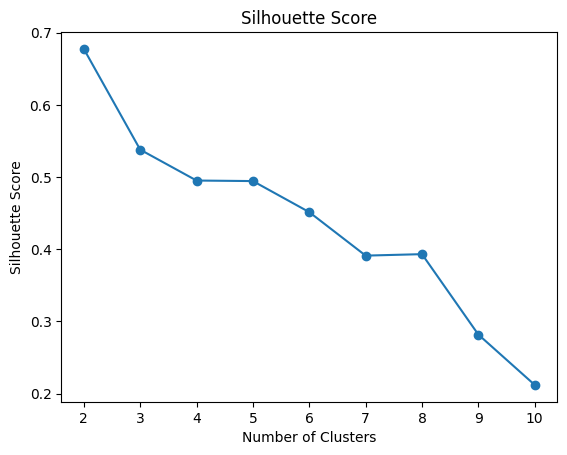

In [15]:
# this is way to show only 1 sillhouette score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2, 11):
    # Create a new AgglomerativeClustering instance for each number of clusters
    agglo_model = AgglomerativeClustering(n_clusters=i, linkage='single')
    cluster_labels = agglo_model.fit_predict(df_combined)
    silhouette_avg = silhouette_score(df_combined, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette Score = the higher the better
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

## Comparing Silhouette Score to get best combination of linkage and metric

Skipping Ward linkage with Manhattan metric (not supported).


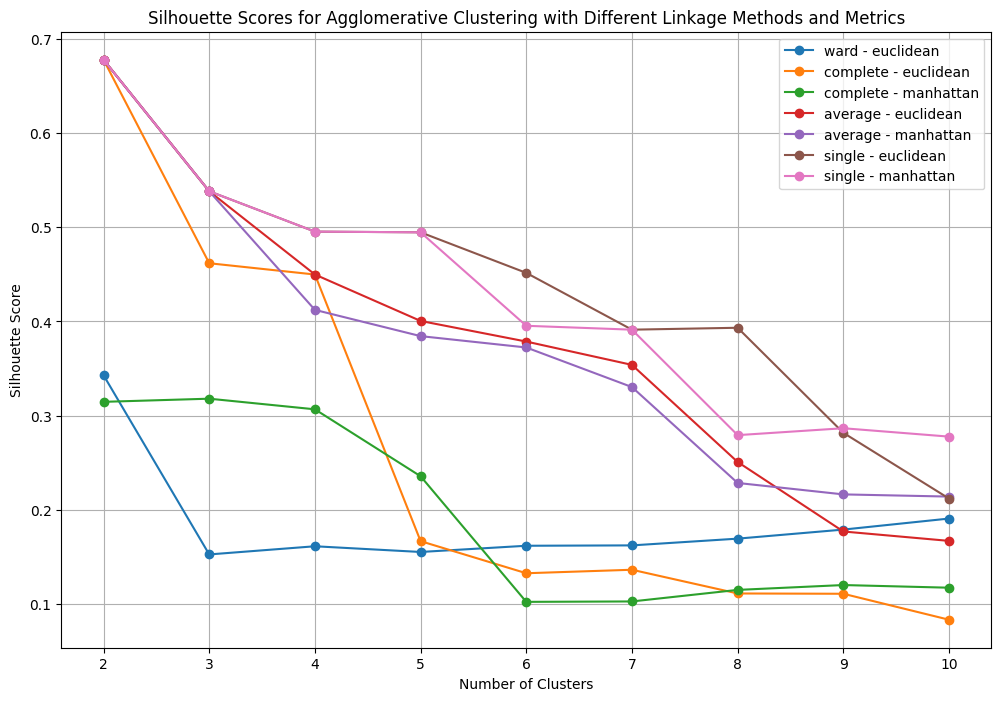

Best Silhouette Score: 0.6776204891746238
Optimal Number of Clusters: 2
Optimal Linkage Method: complete
Optimal Metric: euclidean


In [16]:
# Define the range of clusters to test and linkage methods
range_n_clusters = range(2, 11)
linkage_methods = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan']

best_silhouette_score = -1
best_n_clusters = 0
best_linkage = ''
best_metric = ''

results_for_plotting = []

for linkage_method in linkage_methods:
    for metric in metrics:
        # Skip 'ward' linkage with 'manhattan' metric as it's not supported
        if linkage_method == 'ward' and metric == 'manhattan':
            print(f"Skipping Ward linkage with Manhattan metric (not supported).")
            continue

        current_scores = []
        for n_clusters in range_n_clusters:
            agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method, metric=metric)
            y_agglo = agglo.fit_predict(df_combined)
            silhouette_avg = silhouette_score(df_combined, y_agglo)
            current_scores.append(silhouette_avg)

            if silhouette_avg > best_silhouette_score:
                best_silhouette_score = silhouette_avg
                best_n_clusters = n_clusters
                best_linkage = linkage_method
                best_metric = metric
        results_for_plotting.append({
            'linkage': linkage_method,
            'metric': metric,
            'scores': current_scores
        })

# Plot the silhouette scores for each linkage method and metric combination
plt.figure(figsize=(12, 8))
for result in results_for_plotting:
    plt.plot(range_n_clusters, result['scores'], marker='o', label=f"{result['linkage']} - {result['metric']}")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Agglomerative Clustering with Different Linkage Methods and Metrics")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Silhouette Score: {best_silhouette_score}")
print(f"Optimal Number of Clusters: {best_n_clusters}")
print(f"Optimal Linkage Method: {best_linkage}")
print(f"Optimal Metric: {best_metric}")

## Dendogram Visualization

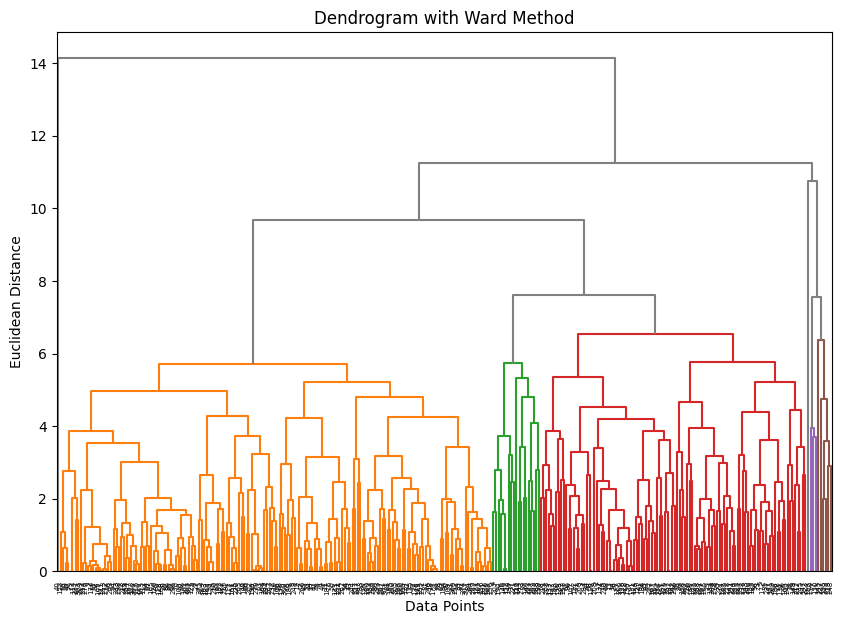

In [17]:
# best Method
linked = linkage(df_combined, method='complete', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked, above_threshold_color="grey", color_threshold=7.5)
plt.title("Dendrogram with Ward Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

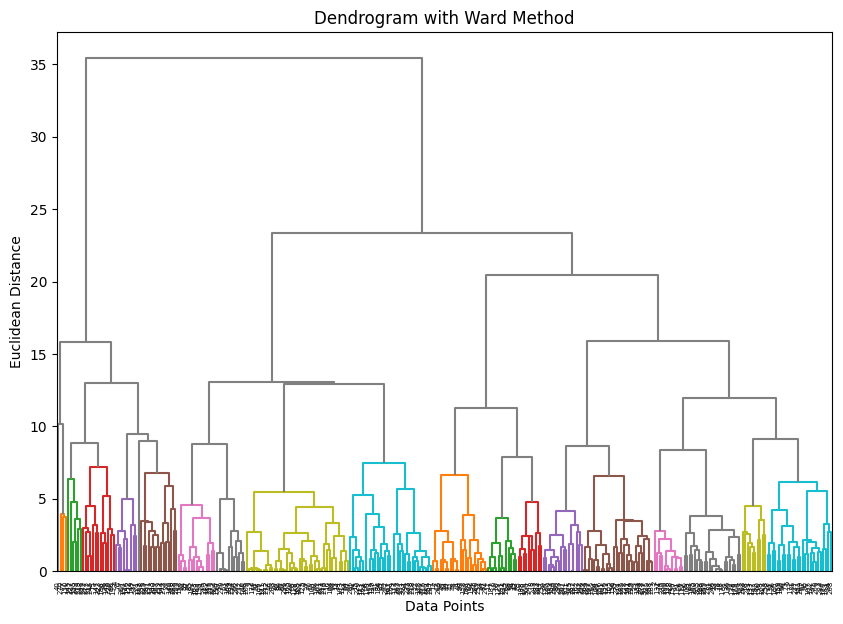

In [18]:
# ward Method
linked = linkage(df_combined, method='ward', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked, above_threshold_color="grey", color_threshold=7.5)
plt.title("Dendrogram with Ward Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

## Hierarchical Clustering Model Best

In [19]:
# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=best_n_clusters, linkage=best_linkage, metric=best_metric)
y_hc = agglo.fit_predict(df_combined)

In [20]:
# Evaluation
ss = silhouette_score(df_combined, y_hc)
print(ss)

0.6776204891746238


##Hierarchical Clustering Model Ward

In [21]:
from scipy.spatial.distance import euclidean
# Hierarchical Clustering
agglo_ward = AgglomerativeClustering(n_clusters=best_n_clusters, linkage='ward', metric= 'euclidean')
y_hc_ward = agglo_ward.fit_predict(df_combined)

In [22]:
# Evaluation
ss = silhouette_score(df_combined, y_hc_ward)
print(ss)

0.34288114831643945


## Dendogram Visualization for Hierarchical Clustering Model

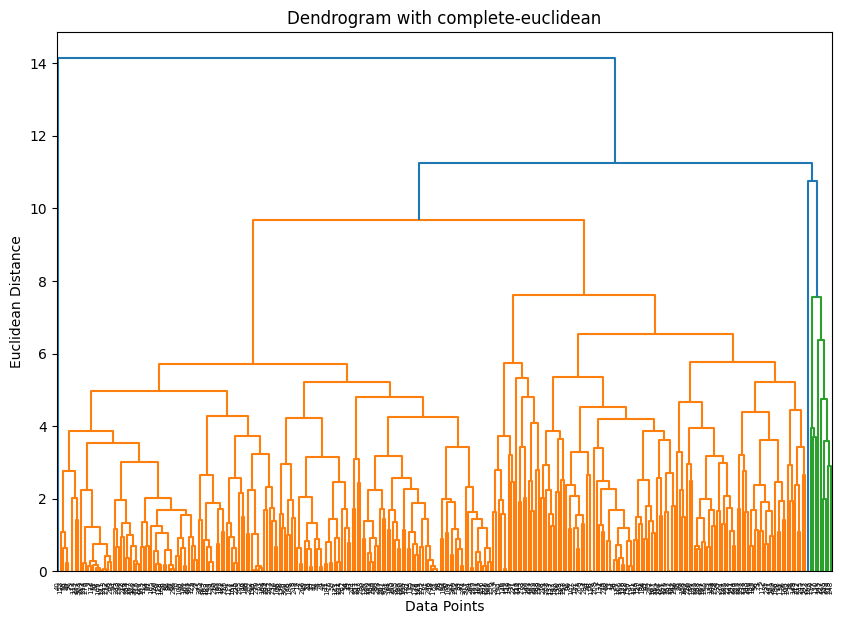

In [23]:
# Average Distance
linked = linkage(df_combined, method=best_linkage, metric=best_metric)

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with " + best_linkage + "-" + best_metric)
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

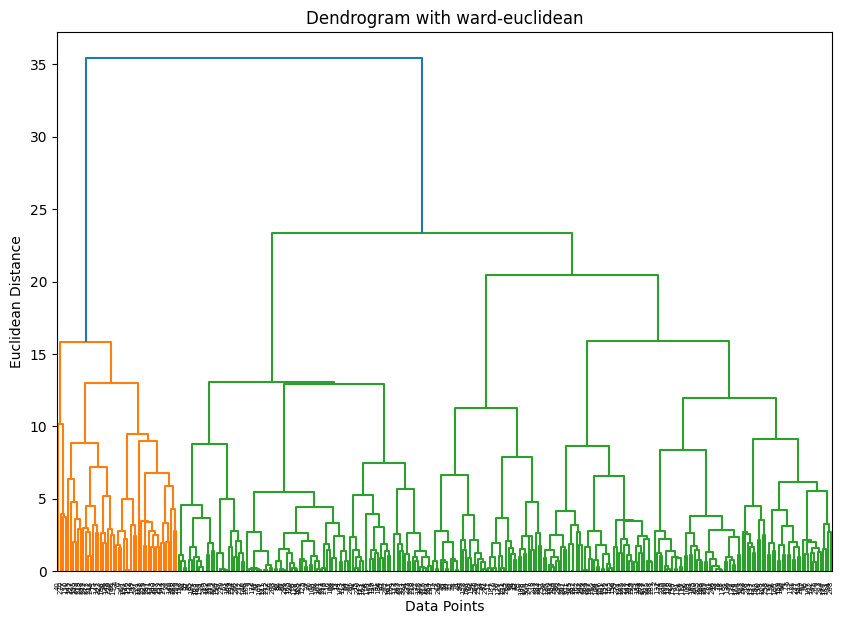

In [24]:
# Average Distance
linked = linkage(df_combined, method='ward', metric='euclidean')

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with " + 'ward' + "-" + 'euclidean')
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

## Merge with the original data

In [25]:
# Add the cluster labels to the original data
df['Agglo'] = y_hc
df['Agglo_ward'] = y_hc_ward
# Analyze the clusters with the original values
df.head()

,Area Category,Luas Tanah,Luas Bangunan,Jumlah Kamar,Jumlah Kamar Mandi,Tingkat/Lantai,Harga Penawaran,Terjual/Belum,Arah Hadap Rumah,Posisi Rumah,lebar Jalan Depan Rumah,Agglo,Agglo_ward
0,3,240,300,4,3,2,3500000000,0,3,2,0,0,0
1,0,30,60,2,1,2,287799000,0,3,2,1,0,0
2,3,170,170,5,4,2,2699999999,0,1,0,0,0,0
3,2,187,250,5,5,2,3100000000,0,3,2,0,0,0
4,1,350,600,5,5,2,5000000000,0,0,2,0,0,1


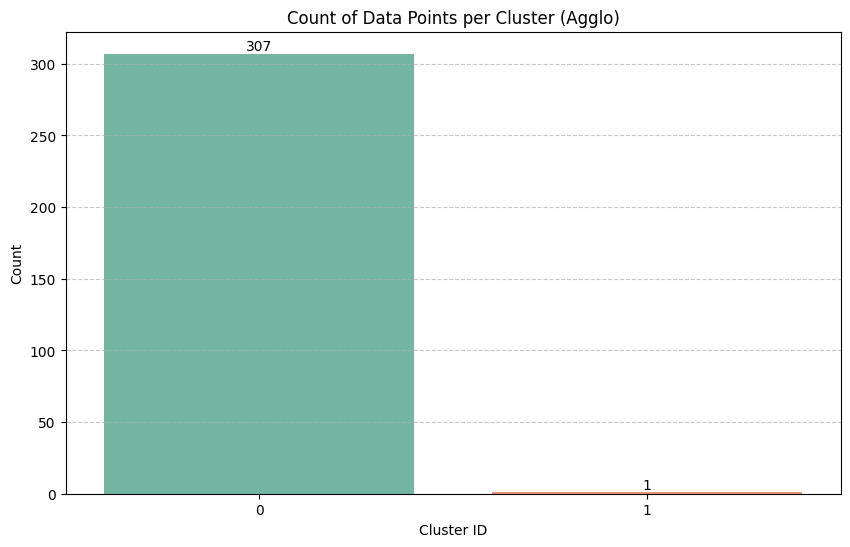

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the counts of each cluster in the 'Agglo' column of df
cluster_counts = df['Agglo'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette='Set2', legend=False)

# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Cluster (Agglo)')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

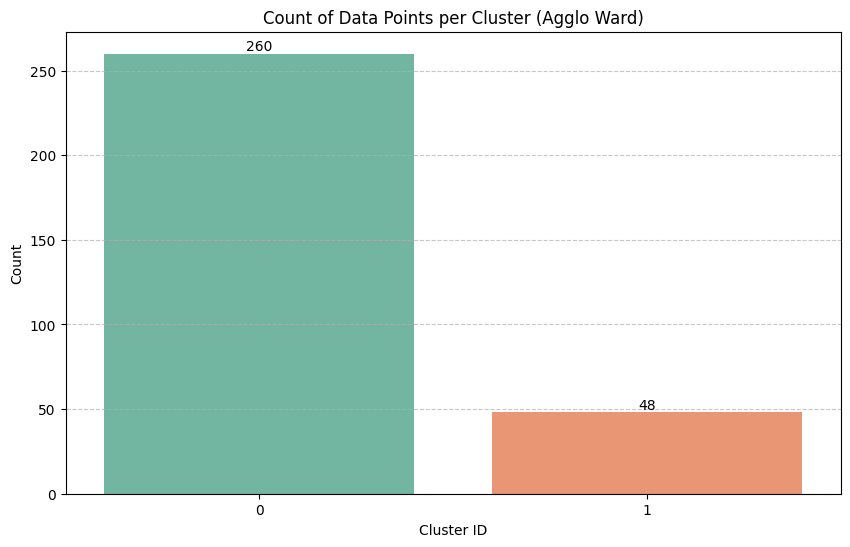

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the counts of each cluster in the 'Agglo' column of df
cluster_counts = df['Agglo_ward'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette='Set2', legend=False)

# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Cluster (Agglo Ward)')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

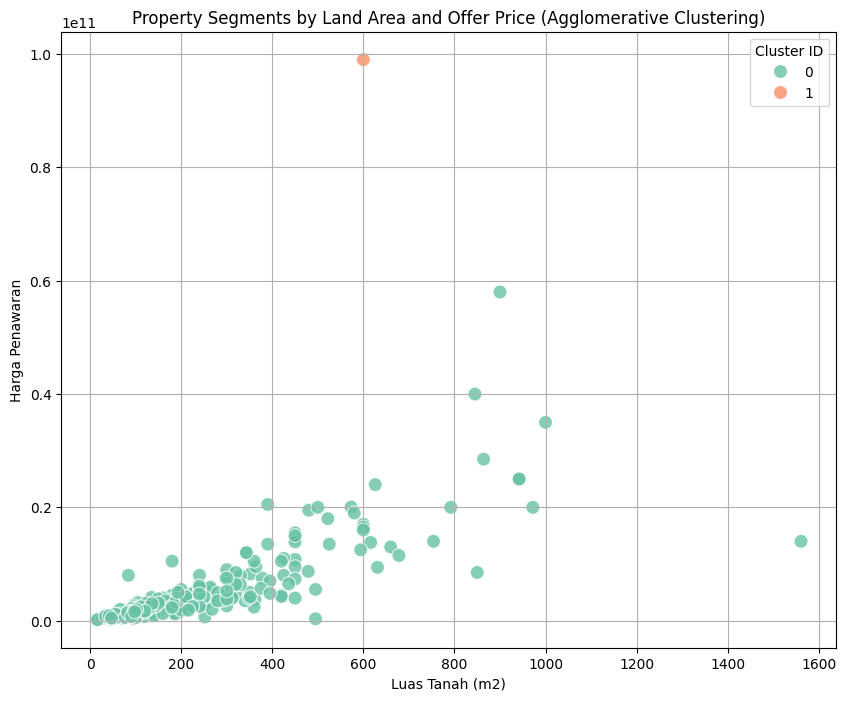

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Luas Tanah', y='Harga Penawaran', hue='Agglo', palette='Set2', s=100, alpha=0.8)
plt.title('Property Segments by Land Area and Offer Price (Agglomerative Clustering)')
plt.xlabel('Luas Tanah (m2)')
plt.ylabel('Harga Penawaran')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()

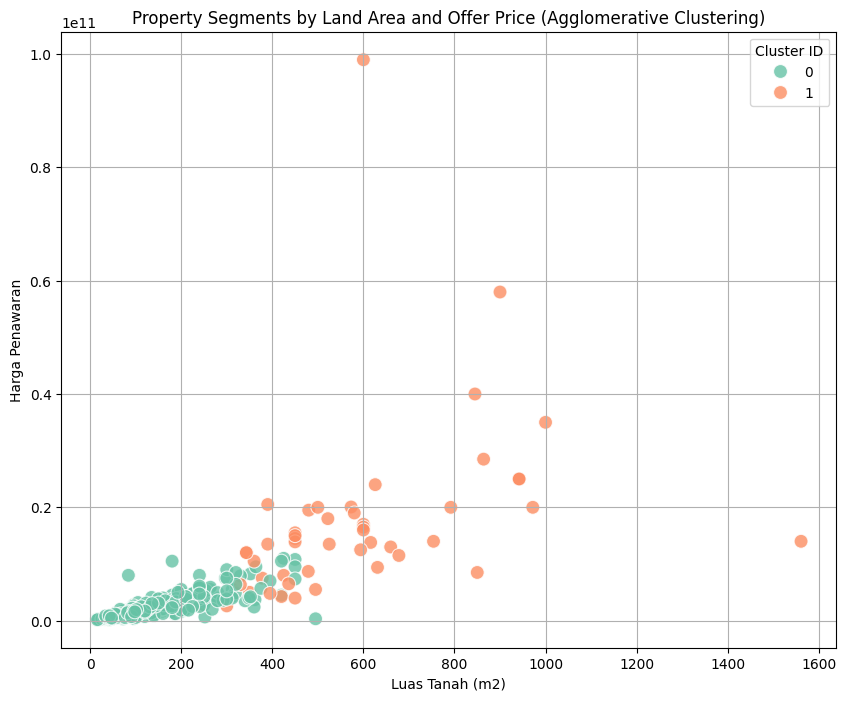

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Luas Tanah', y='Harga Penawaran', hue='Agglo_ward', palette='Set2', s=100, alpha=0.8)
plt.title('Property Segments by Land Area and Offer Price (Agglomerative Clustering)')
plt.xlabel('Luas Tanah (m2)')
plt.ylabel('Harga Penawaran')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.show()

In [30]:
import plotly.express as px

# Define the columns for the 3D scatter plot
x_col = 'Luas Tanah'
y_col = 'Luas Bangunan'
z_col = 'Harga Penawaran'

# Create an interactive 3D scatter plot using Plotly Express
fig = px.scatter_3d(df,
                    x=x_col,
                    y=y_col,
                    z=z_col,
                    color=df['Agglo'].astype(str), # Color points by Agglo cluster, explicitly as string for discrete colors
                    title='Interactive 3D Scatter Plot of Properties by Agglo Clusters')

fig.show()

In [31]:
import plotly.express as px

# Define the columns for the 3D scatter plot
x_col = 'Luas Tanah'
y_col = 'Luas Bangunan'
z_col = 'Harga Penawaran'

# Create an interactive 3D scatter plot using Plotly Express
fig = px.scatter_3d(df,
                    x=x_col,
                    y=y_col,
                    z=z_col,
                    color=df['Agglo_ward'].astype(str), # Color points by Agglo cluster, explicitly as string for discrete colors
                    title='Interactive 3D Scatter Plot of Properties by Agglo Clusters')

fig.show()

## Statistical Summary for each cluster

In [32]:
# Group the data by cluster and calculate summary statistics for relevant numerical columns
cluster_summary = df.groupby('Agglo').agg({
    'Luas Tanah': ['mean', 'std', 'min', 'max'],
    'Luas Bangunan': ['mean', 'std', 'min', 'max'],
    'Jumlah Kamar': ['mean', 'std', 'min', 'max'],
    'Jumlah Kamar Mandi': ['mean', 'std', 'min', 'max'],
    'Tingkat/Lantai': ['mean', 'std', 'min', 'max'],
    'Harga Penawaran': ['mean', 'std', 'min', 'max'],
    'Area Category': ['first', 'count'],
    'Arah Hadap Rumah': ['first', 'count'],
    'Posisi Rumah': ['first', 'count'],
    'lebar Jalan Depan Rumah': ['first', 'count']
})

# Rename the 'first' column to 'mode' for categorical columns
cluster_summary = cluster_summary.rename(columns={'first': 'mode'}, level=1)

cluster_summary = cluster_summary.rename_axis('cluster')

cluster_summary

Luas Tanah                        Luas Bangunan                   \
               mean         std  min   max          mean         std  min   
cluster                                                                     
0        225.736156  201.019246   14  1561    265.602606  212.655015   14   
1        600.000000         NaN  600   600    600.000000         NaN  600   

              Jumlah Kamar            ... Harga Penawaran               \
          max         mean       std  ...             min          max   
cluster                               ...                                
0        1200     4.267101  1.639083  ...       160000000  58000000000   
1         600     7.000000       NaN  ...     99000000000  99000000000   

        Area Category       Arah Hadap Rumah       Posisi Rumah        \
                 mode count             mode count         mode count   
cluster                                                                 
0                   3   307                3   307            2   307   
1                   3     1                0     1            2     1   

        lebar Jalan Depan Rumah        
                           mode count  
cluster                                
0                             0   307  
1                             0     1  

[2 rows x 32 columns]

In [33]:
# Group the data by cluster and calculate summary statistics for relevant numerical columns
cluster_summary = df.groupby('Agglo_ward').agg({
    'Luas Tanah': ['mean', 'std', 'min', 'max'],
    'Luas Bangunan': ['mean', 'std', 'min', 'max'],
    'Jumlah Kamar': ['mean', 'std', 'min', 'max'],
    'Jumlah Kamar Mandi': ['mean', 'std', 'min', 'max'],
    'Tingkat/Lantai': ['mean', 'std', 'min', 'max'],
    'Harga Penawaran': ['mean', 'std', 'min', 'max'],
    'Area Category': ['first', 'count'],
    'Arah Hadap Rumah': ['first', 'count'],
    'Posisi Rumah': ['first', 'count'],
    'lebar Jalan Depan Rumah': ['first', 'count']
})

# Rename the 'first' column to 'mode' for categorical columns
cluster_summary = cluster_summary.rename(columns={'first': 'mode'}, level=1)

cluster_summary = cluster_summary.rename_axis('cluster')

cluster_summary

Luas Tanah                        Luas Bangunan                   \
               mean         std  min   max          mean         std  min   
cluster                                                                     
0        160.653846   95.886936   14   495    198.707692  120.647766   14   
1        586.062500  243.662428  240  1561    634.916667  229.221052  250   

              Jumlah Kamar            ... Harga Penawaran               \
          max         mean       std  ...             min          max   
cluster                               ...                                
0         600     3.907692  1.358208  ...       160000000  11000000000   
1        1200     6.270833  1.633943  ...      2600000000  99000000000   

        Area Category       Arah Hadap Rumah       Posisi Rumah        \
                 mode count             mode count         mode count   
cluster                                                                 
0                   3   260                3   260            2   260   
1                   1    48                0    48            2    48   

        lebar Jalan Depan Rumah        
                           mode count  
cluster                                
0                             0   260  
1                             0    48  

[2 rows x 32 columns]

## Implikasi Manajerial Berdasarkan Hasil Clustering

Berdasarkan hasil *clustering* menggunakan dua metode yang berbeda (Model Terbaik: Agglomerative Clustering dengan *linkage* 'complete' dan *metric* 'euclidean', serta Model Ward: Agglomerative Clustering dengan *linkage* 'ward' dan *metric* 'euclidean'), kita mendapatkan segmentasi properti yang berbeda.

### Analisis Model Terbaik (Agglo)

Model terbaik mengasilkan 2 *cluster*. Berdasarkan ringkasan statistik:

*   **Cluster 0 (n=307)**: Mayoritas properti berada di *cluster* ini. Properti di *cluster* ini memiliki rata-rata luas tanah dan bangunan yang lebih kecil, jumlah kamar dan kamar mandi yang lebih sedikit, serta harga penawaran yang lebih rendah dibandingkan *cluster* 1. Ini merepresentasikan segmen properti yang lebih umum atau standar di pasar.
*   **Cluster 1 (n=1)**: *Cluster* ini hanya terdiri dari satu properti. Properti ini memiliki luas tanah dan bangunan yang jauh lebih besar, jumlah kamar lebih banyak, dan harga penawaran yang sangat tinggi. Ini merepresentasikan segmen properti mewah atau premium yang sangat unik.

**Implikasi Manajerial untuk Model Terbaik:**

*   **Cluster 0**: Fokus pada strategi pemasaran yang menjangkau pasar yang lebih luas. Tawarkan berbagai pilihan properti yang sesuai dengan rata-rata permintaan (ukuran standar, harga menengah). Pertimbangkan promosi yang menarik bagi pembeli pertama atau keluarga muda.
*   **Cluster 1**: Properti di *cluster* ini memerlukan pendekatan pemasaran yang sangat *highly targeted* dan eksklusif. Fokus pada saluran pemasaran properti mewah dan tekankan fitur unik serta nilai investasi dari properti tersebut.

### Analisis Model Ward (Agglo_ward)

Model Ward juga menghasilkan 2 *cluster*. Berdasarkan ringkasan statistik:

*   **Cluster 0 (n=260)**: Sebagian besar properti ada di *cluster* ini. Mirip dengan Cluster 0 pada model terbaik, properti di sini memiliki luas tanah dan bangunan yang lebih kecil, jumlah kamar dan kamar mandi yang lebih sedikit, serta harga penawaran yang lebih rendah. Ini juga mewakili segmen properti standar.
*   **Cluster 1 (n=48)**: *Cluster* ini memiliki jumlah properti yang lebih banyak dibandingkan Cluster 1 pada model terbaik. Properti di *cluster* ini memiliki rata-rata luas tanah dan bangunan yang lebih besar, jumlah kamar dan kamar mandi lebih banyak, serta harga penawaran yang lebih tinggi. Ini merepresentasikan segmen properti premium atau *high-end*.

**Implikasi Manajerial untuk Model Ward:**

*   **Cluster 0**: Strategi pemasaran serupa dengan Cluster 0 pada model terbaik, fokus pada pasar yang lebih luas dan properti standar.
*   **Cluster 1**: Karena jumlah properti yang lebih banyak di segmen premium ini, strategi pemasaran bisa lebih bervariasi. Selain pendekatan eksklusif, pertimbangkan untuk menyoroti keuntungan komparatif properti di *cluster* ini (misalnya, lokasi strategis, fasilitas premium) untuk menarik pembeli yang mencari nilai lebih di segmen atas.

### Perbandingan dan Rekomendasi

Meskipun kedua model menghasilkan 2 *cluster*, distribusi properti dalam *cluster* segmen premium berbeda. Model Terbaik memisahkan satu properti yang sangat ekstrem, sementara Model Ward mengelompokkan properti premium secara lebih luas.

*   **Jika tujuan Anda adalah mengidentifikasi properti yang *benar-benar* unik dan mewah (outlier)**, Model Terbaik (Agglo) memberikan gambaran yang jelas tentang satu properti tersebut.
*   **Jika tujuan Anda adalah mengidentifikasi segmen pasar premium yang lebih besar dan dapat ditargetkan**, Model Ward (Agglo_ward) tampaknya lebih relevan karena mengelompokkan 48 properti dalam satu *cluster* premium.

Pilihan model dan implikasi manajerial yang digunakan akan sangat bergantung pada tujuan spesifik analisis bisnis Anda. Jika fokusnya adalah pada segmentasi pasar secara umum, Model Ward mungkin lebih praktis. Jika ada kebutuhan khusus untuk menganalisis properti ultra-mewah, Model Terbaik memberikan *insight* yang berbeda.